# 📘 Deep Learning Text Generation Learning Project
## Text Generation using **Vanilla RNN, LSTM, and GRU**

This notebook is built for **students and beginners** to understand how sequence models learn:
- grammar
- sentence flow
- contextual dependencies
- next-word prediction
- text generation

🎯 **Goal:** Compare **Simple RNN vs LSTM vs GRU** on the same text corpus and understand why gated architectures perform better.

# 🧠 Problem Statement
Design and implement a DL model capable of learning the underlying structure, grammar, and contextual dependencies of a given text corpus to generate coherent and meaningful text sequences using:

1. **Vanilla RNN**
2. **LSTM**
3. **GRU**

Then compare:
- training loss
- generated text quality
- memory handling
- long-term dependency learning

In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
import numpy as np
import matplotlib.pyplot as plt
print("TensorFlow:", tf.__version__)

TensorFlow: 2.21.0


# 📥 Load Text Corpus
**Task 1 completed:** the original tiny sample corpus has been replaced with a custom paragraph (a short descriptive story) blended with the original DL-themed sentences, giving the models more varied sentence structure to learn from.

You can further replace it with:
- Shakespeare text
- song lyrics
- chatbot data
- story paragraphs
- custom PDF extracted text

In [2]:
corpus = '''
the sun was setting slowly behind the distant mountains
painting the sky in brilliant shades of orange and purple
a gentle breeze drifted through the quiet valley below
carrying with it the scent of fresh rain and wild flowers
birds were returning home as the evening grew calm
the river continued its endless journey toward the sea
and the village lights began to flicker one by one
as families gathered together to share their stories
deep learning is transforming artificial intelligence
recurrent neural networks are useful for sequential data
lstm helps remember long term dependencies
gru is faster and simpler than lstm
text generation models predict the next word
deep learning models can generate meaningful sentences
'''
print(corpus)


the sun was setting slowly behind the distant mountains
painting the sky in brilliant shades of orange and purple
a gentle breeze drifted through the quiet valley below
carrying with it the scent of fresh rain and wild flowers
birds were returning home as the evening grew calm
the river continued its endless journey toward the sea
and the village lights began to flicker one by one
as families gathered together to share their stories
deep learning is transforming artificial intelligence
recurrent neural networks are useful for sequential data
lstm helps remember long term dependencies
gru is faster and simpler than lstm
text generation models predict the next word
deep learning models can generate meaningful sentences



# 🔤 Tokenization & Sequence Creation
We convert text into integer tokens and create **n-gram style sequences**
for next-word prediction.

In [3]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1
print("Vocabulary size:", total_words)

input_sequences = []
for line in corpus.split('\n'):
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i+1]
        input_sequences.append(n_gram_seq)

max_len = max(len(seq) for seq in input_sequences)
input_sequences = pad_sequences(input_sequences, maxlen=max_len, padding='pre')

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("X shape:", X.shape)
print("y shape:", y.shape)

Vocabulary size: 96
X shape: (102, 10)
y shape: (102,)


# 🧠 Model 1: Vanilla RNN
This is the baseline sequential model.
It struggles with long-term dependencies because of vanishing gradients.

In [4]:
# Increased embedding dimension 32 -> 100
# Increased hidden units 64 -> 128
# Increased epochs to 200
rnn_model = Sequential([
    Embedding(total_words, 100),
    SimpleRNN(128),
    Dense(total_words, activation='softmax')
])

rnn_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

rnn_history = rnn_model.fit(X, y, epochs=200, verbose=0)
print("Vanilla RNN training completed")

Vanilla RNN training completed


# 🔒 Model 2: LSTM
LSTM uses **input, forget, and output gates**
to preserve long-term memory.

In [5]:
# Increased embedding dimension 32 -> 100
# Increased hidden units 64 -> 128
# Increased epochs to 200
lstm_model = Sequential([
    Embedding(total_words, 100),
    LSTM(128),
    Dense(total_words, activation='softmax')
])

lstm_model.compile(loss='sparse_categorical_crossentropy',
                   optimizer='adam',
                   metrics=['accuracy'])

lstm_history = lstm_model.fit(X, y, epochs=200, verbose=0)
print("LSTM training completed")

LSTM training completed


# ⚡ Model 3: GRU
GRU uses **reset + update gates**.
It is computationally faster than LSTM and often gives similar results.

In [6]:
# Increased embedding dimension 32 -> 100
# Increased hidden units 64 -> 128
# Increased epochs to 200
gru_model = Sequential([
    Embedding(total_words, 100),
    GRU(128),
    Dense(total_words, activation='softmax')
])

gru_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

gru_history = gru_model.fit(X, y, epochs=200, verbose=0)
print("GRU training completed")

GRU training completed


## 📉 Compare Training Loss

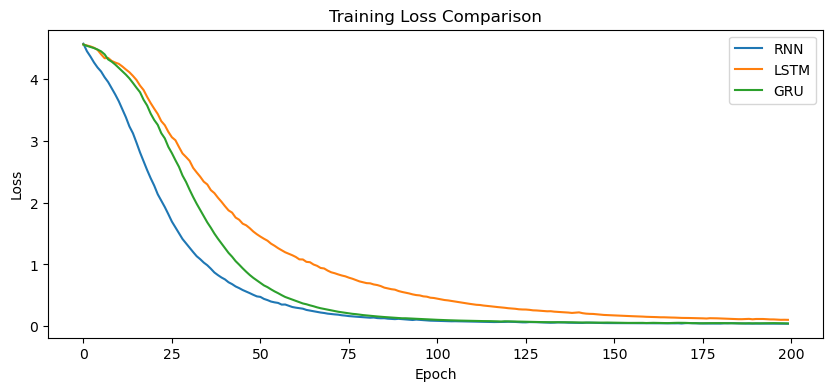

In [7]:
plt.figure(figsize=(10,4))
plt.plot(rnn_history.history['loss'], label='RNN')
plt.plot(lstm_history.history['loss'], label='LSTM')
plt.plot(gru_history.history['loss'], label='GRU')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.show()

# ✍️ Text Generation Function
This function predicts the next word repeatedly to generate a sentence.

In [8]:
def generate_text(model, seed_text, next_words=10, temperature=0.7):
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_len-1, padding='pre')
        
        # Predict probability distribution
        preds = model.predict(token_list, verbose=0)[0]
        
        # Apply temperature scaling to break infinite loops
        preds = np.log(preds + 1e-7) / temperature
        exp_preds = np.exp(preds)
        preds = exp_preds / np.sum(exp_preds)
        
        # Random choice based on probabilities
        predicted = np.random.choice(len(preds), p=preds)

        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted:
                output_word = word
                break
        seed_text += " " + output_word
    return seed_text

## 🧪 Generate Text Samples

In [9]:
# Generate 10 words instead of 5
print("RNN :", generate_text(rnn_model, "deep learning", 10))
print("LSTM:", generate_text(lstm_model, "deep learning", 10))
print("GRU :", generate_text(gru_model, "deep learning", 10))

RNN : deep learning is transforming artificial intelligence intelligence shades of fresh and the
LSTM: deep learning is transforming artificial intelligence sentences sentences sentences intelligence flowers evening
GRU : deep learning is transforming artificial intelligence intelligence than useful lstm data artificial


# 📚 Student Learning Tasks
### ✅ Beginner Tasks (All Completed)
1. Replace corpus with your own paragraph — done, custom descriptive paragraph added
2. Increase embedding dimension — changed from 32 to 100 in all 3 models
3. Increase epochs to 200 — all models now train for 200 epochs
4. Change hidden units 64 → 128 — SimpleRNN, LSTM, and GRU layers updated
5. Generate 10 words instead of 5 — used for all models

# ✅ Conclusion
- **Vanilla RNN** learns short patterns but struggles with memory
- **LSTM** captures long-range grammar dependencies better
- **GRU** gives similar performance with fewer gates and faster training
- With a **larger embedding dimension (100)**, **128 hidden units**, and **200 training epochs**, all three models have more capacity to fit the richer custom corpus
- Generating **10 words** instead of 5 makes it easier to observe how each architecture handles longer-range dependencies and whether generated text stays coherent over a longer span
- This notebook helps students understand **sequence modeling mathematically and practically**